In [1]:
import numpy as np
import time, pickle, copy
import random, os, re
from typing import Callable, Dict, Optional, Union
import uuid
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
random.seed(42)

In [2]:
import numpy as np
import time, pickle, copy
import random, os, re
from typing import Callable, Dict, Optional, Union
import uuid
import matplotlib.pyplot as plt
import pandas as pd
import plotly as px
random.seed(42)


class SSO():
    def __init__(
        self,
        Ngen: int,                                      # 迭代數
        Nsol: int,                                      # 解的數量
        Cg: float,                                      # 全局最佳解的權重
        Cp: float,                                      # 個體最佳解的權重
        Cw: float,                                      # 隨機解的權重
        save_name: str,                                 # 記錄檔儲存，可自定義前綴
        fitness: Callable,                              # 適應度函數
        base_param: Optional[Dict] = None,              # 基礎參數 (可選)
        boundary: Dict[str, Union[tuple, list]] = None, # 支持 tuple 或 list
        direction: str = "minimize"                     # 優化方向
        ):

        """
        初始化方法，用於設置算法的參數和邊界條件。

        Parameters:
            Ngen (int): 生成的世代數。
            Nsol (int): 解的數量。
            Cg (float): 全局最佳解權重。
            Cp (float): 個體最佳解權重。
            Cw (float): 隨機解權重。
            save_name (str): 模型存儲路徑。
            fitness (callable): 適應度函數。
            base_param (dict): 基本參數（默認為 None，全部的解都隨機產生/若不是None則作為第0代第0個解）。
            boundary (dict): 每個變數的上下界範圍，格式為 {param_name: (lower_bound, upper_bound)}。
            direction (str) : 優化方向。 ('minimize' / 'maximize')
        """

        self.Ngen = Ngen
        self.Nsol = Nsol
        self.fitness=fitness
        #....................
        self.boundary=boundary
        self.lower_bounds = np.array([b[0] for b in boundary.values()])
        self.upper_bounds = np.array([b[1] for b in boundary.values()])
        self.Nvar = len(self.boundary)
        #....................
        self.Cg = Cg
        self.Cp = Cp
        self.Cw = Cw
        self.gBest = 0
        self.genBest = 0
        # ....................
        self.X = np.zeros((Nsol, self.Nvar))
        self.pX = np.zeros((Nsol, self.Nvar))
        self.F = np.zeros(Nsol, dtype=float)
        self.pF = np.zeros(Nsol, dtype=float)

        # ....................自定義初始解
        self.base_param=base_param

        # ....................更新方向
        if direction not in ("minimize", "maximize"):
            raise ValueError("Direction must be either 'minimize' or 'maximize'.")
        self.direction = direction
        self.flag = 1 if self.direction == 'minimize' else -1

        # ....................CHECKPOINT，ckpt結構設計
        # ckpt = {
        #     gen (int): {  # 每一代 (generation)
        #         sol (int): {  # 每個解 (solution)
        #             'g': (g_params (List), g_value (float)),  # 全局 最佳參數與其適應度值
        #             'p': (p_params (List), p_value (float)),  # 個體 最佳參數與其適應度值
        #             'X': (x_params (List), x_value (float))), # 該解 當前參數與其適應度值
        #             'message': Dict   # 記錄信息，可在 fitness 函數中自定義，例如:
        #                 { 
        #                     'val_acc': float,   # 驗證準確率
        #                     'test_acc': float,  # 測試準確率
        #                     'train_time': float # 訓練時間
        #                 }
        #         }
        #     }
        # }
        # 
        # 使用說明：
        # - 允許通過 ckpt[gen][sol] 快速獲取指定代 (generation) 和解 (solution) 的相關數據。
        # - 支援查詢全局最佳值 ('g')、個體最佳值 ('p')、參數值 ('params') 和紀錄數據 ('message')。
        # - record_message 結構可在 fitness 函數中根據需要進行自定義。
        self.ckpt = {}

        # ....................CHECKPOINT，ckpt結構設計
        self.save_name = save_name # 僅作為紀錄檔的前綴
        self.save_path = None       # 紀錄檔的儲存路徑。

        # ....................log_dir，每次更新存log使用
        self.log_dir = r'sso_checkpoint/'
        self.log_path = self.log_dir + 'log.pkl'

        # ....................紀錄SSO優化時間，會一併記錄在ckpt檔案名稱上。
        self.search_time = 0
        
        # ....................用以紀錄搜索後的最佳解/或ckpt讀入後的gbest最佳解。
        self.best_params = None

        self.resume_flag = None

    def run(self):  # 暖啟動寫這裡?
        
        # 建立 log 目錄（如果不存在）
        os.makedirs(self.log_dir, exist_ok=True)

        # 建立 log.pkl（如果不存在）
        if not os.path.exists(self.log_path):  
            with open(self.log_path, 'wb') as file:
                pass  
            print(f"Created a new log file: {self.log_path}")
        
        start_time = time.time()

        # 初始化記錄檔，允許通過 ckpt[gen][sol] 快速查詢
        for gen in range(self.Ngen+1):
            self.ckpt.setdefault(gen, {})

        # Initialize in Gen 0
        for sol in range(self.Nsol):
                self.INIT(sol)

        for gen in range(1, self.Ngen+1):
            for sol in range(self.Nsol):
                self.UPDATE(sol, gen)

        self.best_params = copy.deepcopy(self.pX[self.gBest])

        end_time = time.time()
        self.search_time = end_time - start_time

        unique_id = uuid.uuid4().hex[:8]  # 唯一識別代號，避免有搜尋結果相同的問題
        self.save_path = f"sso_result/{self.save_name}_ggen{self.genBest}_gsol{self.gBest}_searchtime{self.search_time}_{unique_id}.pkl"
        
        # 確保目錄存在
        os.makedirs(os.path.dirname(self.save_path), exist_ok=True)
        with open(self.save_path, 'wb') as f:
            pickle.dump(self.ckpt, f)
        print(f"📄 記錄檔已儲存至：{self.save_path}")
        print("-" * 40)

        os.remove(self.log_path) #如果實驗完成，就在最後把log刪除

        # 打印輸出
        self.result_summary()

    def INIT(self, sol):
        """
        初始化。
        """
        # 如果有基準值，gen:0/sol:0 使用base_param
        if sol == 0 and self.base_param is not None:
            # 过滤 base_param，只保留 keys 在 params_range 中的值
            filtered_params = {k: v for k, v in self.base_param.items() if k in self.boundary}
            # 将过滤后的值转换为 NumPy 数组
            self.X[sol] = np.array(list(filtered_params.values()))
        else:
            self.X[sol] = self.generate_random_sol()     #隨機生成
        
        # 計算Fitness & Record
        self.F[sol], record_message = self.fitness(self.X[sol])

        # Gen:0, pBest直接賦值
        self.pX[sol] = copy.deepcopy(self.X[sol])
        self.pF[sol] = self.F[sol]
        
        # gBest指向最好的sol (index)
        if self.F[sol]*self.flag < self.F[self.gBest]*self.flag:
            self.gBest = sol
            
        self.ckpt_update(gen=0, sol=sol, record_message=record_message) #記錄檔更新

    def UPDATE(self, sol, gen):
        """
        Update the solution's variable values based on random numbers and conditional masks.
        
        Parameters:
            sol (int): Index of the solution.
            gen (int): Current generation number.
        """
        rnd_list = np.random.rand(self.Nvar)                         # 生成 Nvar 個隨機數
        rnd_sol = self.generate_random_sol()                         # 生成一個全隨機解

        # 條件遮罩
        mask_Cg = rnd_list < self.Cg                                 # 滿足 Cg 條件
        mask_Cp = (rnd_list >= self.Cg) & (rnd_list < self.Cp)       # 滿足 Cp 條件
        mask_random = rnd_list > self.Cw                             # 滿足隨機生成條件

        # 使用遮罩更新解
        self.X[sol, mask_Cg] = self.pX[self.gBest, mask_Cg]          # 使用 gBest
        self.X[sol, mask_Cp] = self.pX[sol, mask_Cp]                 # 使用 pBest
        self.X[sol, mask_random] = rnd_sol[mask_random]              # 使用 random

        self.F[sol], record_message = self.fitness(self.X[sol])

        if self.F[sol]*self.flag < self.pF[sol]*self.flag:
            self.pF[sol] = self.F[sol]
            self.pX[sol] = copy.deepcopy(self.X[sol])
            if self.F[sol]*self.flag < self.pF[self.gBest]*self.flag:
                self.gBest = sol
                self.genBest = gen

        self.ckpt_update(gen=gen, sol=sol, record_message=record_message) #記錄檔更新

    def generate_random_sol(self):
        """
        Generate a random solution based on the boundaries defined for each variable.
        
        The method processes different boundary types:
            - If the boundary is a tuple:
                - If both values are integers, it generates a random integer within the range [lower, upper].
                - If either value is a float, it generates a random float within the range [lower, upper).
            - If the boundary is a list:
                - It randomly selects one value from the list.
        
        Returns:
            np.ndarray: An array of random values (integers, floats, or categorical) generated according to the boundaries.
        """

        random_solution = []

        for key, boundary in self.boundary.items():
            # 處理 tuple 邊界
            if isinstance(boundary, tuple):
                lower, upper = boundary
                if isinstance(lower, int) and isinstance(upper, int):  # 整數範圍
                    random_solution.append(np.random.randint(lower, upper + 1))
                else:  # 浮點數範圍
                    random_solution.append(np.random.uniform(lower, upper))
            
            # 處理 list 邊界
            elif isinstance(boundary, list):
                random_solution.append(np.random.choice(boundary))  # 隨機選擇列表中的一項
            
            # 如果邊界類型無效
            else:
                raise ValueError(f"Unsupported boundary type for variable {key}: {boundary}")

        return np.array(random_solution)

    def ckpt_update(self, gen, sol, record_message):
        solution = tuple(self.X[sol].copy())
        self.ckpt[gen][sol] = {
            'x'         : (solution, self.F[sol]),                                                              # X, F
            'message'   : record_message,                                                                       # record message
            'p'         : (tuple(self.pX[sol].copy()), self.pF[sol]),                                           # pX, pF
            'g'         : (tuple(self.pX[self.gBest].copy()), self.pF[self.gBest], self.genBest, self.gBest),   # gX, gF
        }

        # 直接存檔
        log_message = f'Gen : {gen:>3} | Sol : {sol:>3} | record_message : {record_message} | params : {solution} | fitness : {self.F[sol]}'
        self.print_log(log_message)  # print and save ckpt (pkl).

    def print_log(self, str, print_time=True):

        if print_time:
            localtime = time.asctime(time.localtime(time.time()))
            log = "[ " + localtime + ' ] ' + str
        print(log)

        with open(self.log_path, 'wb') as f:
            pickle.dump(self.ckpt, f)

    def result_summary(self):
        print("=" * 40)
        print("🚀 Search Results Summary")
        print("=" * 40)

        print(f"✅ Search 完成！")
        print(f"🔍 最佳解所在世代編號：{self.genBest}")
        print(f"🔍 最佳解索引編號：{self.gBest}")
        print("-" * 40)

        print("🏆 Optimal Solution Details:")
        print(f"  - Optimal Solution: {self.ckpt[self.genBest][self.gBest]}")
        print(f"  - Optimal Fitness Value: {self.pF[self.gBest]:.6f}")
        print("-" * 40)

        if self.resume_flag:
            print(f"這是接續優化的時間，請自行補上之前的運行時間")
        print(f"⏱️ SSO Search Total Time: {self.search_time:.2f} seconds")
        print("=" * 40)

        # self.load(self.save_dir)

    def plot(self):
        # 设置全局字体大小
        plt.rcParams.update({'font.size': 18})
        # ---------------- 第一张图，pbest 对 gen 作图 ----------------
        # 将 self.ckpt 转换为 DataFrame
        data = []
        for gen, sol_data in self.ckpt.items():
            for sol, values in sol_data.items():
                data.append({
                    'gen': gen,
                    'sol': sol,
                    'pbest': values['p'][1],  # Personal best fitness
                    'gbest': values['g'][1]  # Global best fitness
                })

        df = pd.DataFrame(data)

        # 绘制每个 sol 的 pbest 随 gen 的变化
        plt.figure(figsize=(10, 6))
        for sol, group in df.groupby('sol'):
            plt.plot(group['gen'], group['pbest'], label=f"sol {sol}", marker='o')  # 折线图

        # 图表装饰
        plt.title("Fitness Value Evolution per sol")
        plt.xlabel("Generation (gen)")
        plt.ylabel("Fitness Value (pbest)")
        plt.grid(alpha=0.3)
        plt.legend(title="sol")
        plt.xticks(sorted(df['gen'].unique()))  # 确保 x 轴仅显示生成的代数
        plt.show()

        # ---------------- 第二张图，gbest 对 gen 作图 ----------------
        # 按 gen 计算全局最佳适应度
        if self.flag == 1:  # 假设 flag 表示最小化或最大化
            gbest_df = df.groupby('gen')['gbest'].min().reset_index()  # 最小化目标
        else:
            gbest_df = df.groupby('gen')['gbest'].max().reset_index()  # 最大化目标

        # 绘制全局最佳适应度随 gen 的变化
        plt.figure(figsize=(8, 6))
        plt.plot(gbest_df['gen'], gbest_df['gbest'], marker='o', color='red', label='Global Fitness Value')  # 折线图

        # 图表装饰
        plt.title("Global Fitness Value per Generation")
        plt.xlabel("Generation (gen)")
        plt.ylabel("Fitness Value (gbest)")
        plt.xticks(sorted(df['gen'].unique()))  # 确保 x 轴仅显示生成的代数
        plt.grid(alpha=0.3)
        plt.legend()
        plt.show()

    def load_result(self, result_file:str):
        try:
            if os.path.exists(result_file):
                print("\n🔄 Loading from saved checkpoint...")
                # 提取 ggen 和 gsol 的值

                # 读取保存的文件
                with open(result_file, 'rb') as f:
                    self.ckpt = pickle.load(f)

                print(f"📂 File ggen: {self.genBest}, gsol: {self.gBest}")

                #------------------------------------------------- 檢測是否有資訊
    
                # 過濾掉空的 gen，確保選擇的 gen 內有 sol
                valid_gens = [g for g in self.ckpt.keys() if self.ckpt[g]]  # 只保留非空的 gen

                if valid_gens:  # 如果有合法的 gen
                    gen = max(valid_gens)  # 選擇最大 gen
                    sol = max(self.ckpt[gen].keys())  # 找到該 gen 內的最大 sol
                else:
                    print(f'we can not find the valid gen')
                
                #------------------------------------------------- 重建之前優化的狀態

                self.genBest = self.ckpt[gen][sol]['g'][2]
                self.gBest = self.ckpt[gen][sol]['g'][3]

                # 获取记录并打印 message
                if self.genBest in self.ckpt and self.gBest in self.ckpt[self.genBest]:
                    self.best_params = np.array(copy.deepcopy(self.ckpt[self.genBest][self.gBest]['x'][0]))
                    best_fitness = self.ckpt[self.genBest][self.gBest]['x'][1]
                    record_message= self.ckpt[self.genBest][self.gBest]['message']
                    print("========================================")
                    print("📝 Record Information")
                    print("========================================")
                    print(f"🔍 Record Message: {record_message}")
                    print(f"🔧 Parameters: {self.best_params}")
                    print(f"🏆 Fitness: {best_fitness}")
                    print("========================================")
                    
                else:
                    print("❌ Record not found in saved checkpoint!")
            else:
                print("❌ Unable to extract ggen and gsol from filename.")

        except Exception as e:
            print(f"⚠️ Error while reading checkpoint: {e}")
   
    def sensitivity_analysis(self, files: list, y_value: str = 'val_acc', label_map: dict = None):

        param_data = []
        fitness_data = []
        param_names = list(self.boundary.keys())  # 获取参数名称

        # 加载数据
        for f in files:
            self.load(f)
            for gen, gen_data in self.ckpt.items():
                for sol, sol_data in gen_data.items():
                    param_data.append(sol_data['params'])
                    fitness_data.append(sol_data['message'][y_value])  # 保存适应度值

        # 转换为 DataFrame
        param_df = pd.DataFrame(param_data, columns=param_names)
        param_df['fitness'] = fitness_data  # 将 y_value 添加为 fitness 列

        # 提前映射 label_map 的参数为均匀索引值
        value_to_label_map = {}
        dimension_ranges = {}  # 用於存儲每個參數的上下界範圍
        if label_map:
            for param, labels in label_map.items():
                if param not in self.boundary:
                    raise ValueError(f"label_map 中的键 {param} 不存在于参数范围中！")
                if isinstance(self.boundary[param], list) and len(labels) != len(self.boundary[param]):
                    raise ValueError(f"参数 {param} 的 label_map 长度与 boundary 中的值不一致！")

                # 提前映射为均匀分布索引
                original_values = self.boundary[param]
                uniform_indices = list(range(len(labels)))  # 均匀索引
                value_to_label = dict(zip(original_values, labels))  # 原始值 -> 标签
                value_to_uniform = dict(zip(original_values, uniform_indices))  # 原始值 -> 均匀索引

                # 更新数据
                param_df[param] = param_df[param].map(value_to_uniform)
                value_to_label_map[param] = value_to_label
                dimension_ranges[param] = [0, len(labels) - 1]  # 映射後範圍

        # 處理非 label_map 的參數，直接從 boundary 中獲取上下界
        for param in self.boundary:
            if param not in dimension_ranges:
                if isinstance(self.boundary[param], tuple):  # 连续范围
                    dimension_ranges[param] = [self.boundary[param][0], self.boundary[param][1]]
                elif isinstance(self.boundary[param], list):  # 离散值
                    dimension_ranges[param] = [min(self.boundary[param]), max(self.boundary[param])]

        # 分组绘制，每组包含最多 5 个参数
        num_params = len(param_names)
        group_size = 5
        num_groups = (num_params + group_size - 1) // group_size  # 向上取整

        for group_idx in range(num_groups):
            start_idx = group_idx * group_size
            end_idx = min(start_idx + group_size, num_params)
            group_params = param_names[start_idx:end_idx]

            # 获取当前组的参数数据
            plot_df = param_df[group_params]

            # 绘制平行坐标图
            fig = px.parallel_coordinates(
                plot_df,
                dimensions=group_params,
                color=param_df['fitness'],  # 使用调整后的 fitness 进行颜色映射
                color_continuous_scale='Viridis' if self.flag == 1 else 'Viridis_r',  # 颜色映射
                labels={param: param for param in group_params},  # 初始標籤
                title=f"Sensitivity Analysis (Params {start_idx + 1}~{end_idx})"
            )
            fig.update_coloraxes(colorbar_title="Fitness")

            # 更新维度的范围和标签
            for dim in fig.data[0]['dimensions']:
                param = dim['label']
                if param in dimension_ranges:
                    dim['range'] = dimension_ranges[param]  # 设置上下界

                # 更新分类参数的标签（label_map）
                if param in value_to_label_map:
                    dim['ticktext'] = list(value_to_label_map[param].values())
                    dim['tickvals'] = list(range(len(value_to_label_map[param])))
            
            # 显示图表
            fig.show()            

    def resume_run(self, log_file: str):

        with open(log_file, 'rb') as f:
            self.ckpt = pickle.load(f)

        #------------------------------------------------- 檢測是否有資訊
      
        # 過濾掉空的 gen，確保選擇的 gen 內有 sol
        valid_gens = [g for g in self.ckpt.keys() if self.ckpt[g]]  # 只保留非空的 gen

        if valid_gens:  # 如果有合法的 gen
            gen = max(valid_gens)  # 選擇最大 gen
            sol = max(self.ckpt[gen].keys())  # 找到該 gen 內的最大 sol
        else:
            print(f'we can not find the valid gen')
        
        #------------------------------------------------- 重建之前優化的狀態

        self.genBest = self.ckpt[gen][sol]['g'][2]
        self.gBest = self.ckpt[gen][sol]['g'][3]
        
        for s in range(self.Nsol):
            # 從ckpt裡面挖資訊，並重建
            self.pX[s] = np.array(self.ckpt[gen][s]['p'][0]) if self.ckpt[gen][s] else np.array(self.ckpt[gen-1][s]['p'][0])
            self.pF[s] = np.array(self.ckpt[gen][s]['p'][1]) if self.ckpt[gen][s] else np.array(self.ckpt[gen-1][s]['p'][1])

            self.X[s] = np.array(self.ckpt[gen][s]['x'][0]) if self.ckpt[gen][s] else np.array(self.ckpt[gen-1][s]['x'][0])
            self.F[s] = np.array(self.ckpt[gen][s]['x'][1]) if self.ckpt[gen][s] else np.array(self.ckpt[gen-1][s]['x'][1])

        #------------------------------------------------- gen、sol 更新至下個行動點

        # 因為是接續進行，所以如果存在的sol已經到粒子的最大數量，就從下個gen開始。
        if sol == self.Nsol-1:
            gen += 1
            sol = 0 
        # 如果還沒跑完當個gen，就從下一個sol繼續。
        else:
            sol += 1

        # 此情況發生於 前一次僅跑50gen，但後續想補至100gen，會造成字典查找不到gen51以後
        for g in range(gen, self.Ngen+1):
            print(g)
            self.ckpt.setdefault(g, {})

        # 正式重啟
        self.resume_flag = True
        start_time = time.time()
        
        #------------------------------------------------- 繼續優化

        # 考慮init還沒跑完
        if gen == 0:
            # 把初始化完成
            for s in range(sol, self.Nsol):
                self.INIT(s)

        # 考慮當前gen沒跑完
        if sol != 0:
            for s in range(sol, self.Nsol):
                self.UPDATE(s, gen)
            gen += 1
        
        # 跑完剩下的gen
        for g in range(gen, self.Ngen+1):
            for s in range(self.Nsol):
                self.UPDATE(s, g)

        #------------------------------------------------- 優化結束

        end_time = time.time()
        self.best_params = copy.deepcopy(self.pX[self.gBest])

        self.search_time = end_time - start_time

        unique_id = uuid.uuid4().hex[:8]  # 唯一識別代號，避免有搜尋結果相同的問題
        self.save_path = f"sso_result/{self.save_name}_ggen{self.genBest}_gsol{self.gBest}_searchtime{self.search_time}_{unique_id}.pkl"
        
        # 確保目錄存在
        os.makedirs(os.path.dirname(self.save_path), exist_ok=True)
        with open(self.save_path, 'wb') as f:
            pickle.dump(self.ckpt, f)
        print(f"📄 記錄檔已儲存至：{self.save_path}")
        print("-" * 40)

        os.remove(self.log_path) #如果實驗完成，就在最後把log刪除

        # 打印輸出
        self.result_summary()
        



# **1. 初始化參數設定**
   - A.自訂參數初始化  
   - B.搜索範圍設定  
   - C.適應度函數設定

---

## A.自訂初始化參數

### 用途
- 可自訂特定參數的初始值。
- 可選擇不調整某些參數，直接使用固定值。

### 範例
```python
params = {
    'x1': 0,        # 初始化為 0
    'x2': 2,        # 初始化為 2
    'x3': 5,        # 初始化為 5
    'x4': 2,        # 初始化為 2
    'x5': 0.3,      # 初始化為 0.3
    'x6': 1,        # 固定為 1，不參與搜索
    'x8': 8         # 固定為 8，不參與搜索
}

In [3]:
params = {
    'x1': 0,
    'x2': 2,
    'x3': 5,
    'x4': 2,
    'x5': 0.3,
    'x6': 1,
    'x8': 8,
}

---
## B.搜索範圍設定

**📦 結構說明**
- 搜索範圍使用 **字典 (Dict)** 結構定義，每個參數的範圍可以是：
  - **Tuple**：用於指定上下界。
  - **List**：用於列舉固定選項。

---

**💡 支援格式**

**B-1. Tuple (上下界範圍)**
- 用於定義參數的連續範圍。
- 如果上下界為 **整數**，內部會自動將範圍的上界增加 1，確保整數範圍完全包含。
- 如果上下界為 **浮點數**，輸出將根據需要生成浮點數。

**B-2. List (選項)**
- 用於列舉參數的固定值，僅支援 `float` 或 `int`。
- 如果需要處理 **字串類型參數**，請額外使用映射 (`map`) 方法進行轉換。

---

**📚 示例**
```python
params_range = {
    'x1': (-10.0, 10.0),   # 搜索範圍為 -10.0 到 10.0
    'x2': (-125, 135),     # 搜索範圍為 -125 到 135
    'x3': (-500, 500),     # 搜索範圍為 -500 到 500
    'x4': [1, 2, 5],       # 可選值為 1, 2, 5
    'x5': (-0.12, 1.38)    # 搜索範圍為 -0.12 到 1.38
}

In [4]:
params_range = {
    'x1': (-10.0, 10.0),
    'x2': (-125, 135),
    'x3': (-500, 500),
    'x4': [1, 2, 5],
    'x5': (-0.12, 1.38)
}

---
##  C.適應度函數設定

**🔧`get_param` 函數**

**可以不用動**

**功能**
- 將數組 `X` 中的值映射到指定的參數名稱（`keys`）中，並更新目標字典 `params`。

---

**🔧`fitness` 函數**

**功能**
- 用以獲取適應度函數值，需回傳 `fitness_value` 和 `record_message`。
- **`fitness_value`**：用以作為 SSO 迭代的數值。
- **`record_message`**：作為每個世代 (gen) 和每個解 (sol) 的紀錄資訊。

- **記得要在輸入時限制型態**。

In [5]:
def get_param(X, keys=params_range.keys(), params=params):
    """
    Update `param` dictionary based on `keys` and corresponding values from `X`.

    Parameters:
        X (numpy.ndarray): Array of parameter values corresponding to the keys.
        keys (list): List of parameter names (keys) used to map values in X.
        params_range (dict): Search range for each parameter, where values can be
                             tuples (for range) or lists (for discrete options).

    Returns:
        dict: Updated `param` dictionary with values from `X`, converting to int if needed.
    """
    # 創建 `param` 的拷貝，避免修改原始字典
    param = params.copy()

    # 根據 keys 中的索引更新 param 中對應的鍵
    for i, key in enumerate(keys):
        # 判斷該參數是否需要轉換為整數
        boundary = params_range[key]
        if (
            isinstance(boundary, tuple) and all(isinstance(b, int) for b in boundary)
        ) or (
            isinstance(boundary, list) and all(isinstance(b, int) for b in boundary)
        ):
            # 如果是整數範圍或整數列表，將值轉換為整數
            param[key] = int(X[i])
        else:
            # 否則保留原類型
            param[key] = X[i]

    return param

# ......................

def fitness(X):
    """
    Fitness function

    Parameters:
        X (numpy.ndarray): Array of parameter values for the model.
                           The array is expected to be a 1D array where each element corresponds 
                           to a specific parameter defined in `params_range.keys()`.

                           Example:
                           X = [best_weight_decay_1, best_lamda, best_al, best_earlystop, ...]

    Returns:
        fitness_value (float): Calculated fitness value based on the parameter values in X.
        record_message (dict): Dictionary containing the following metrics:
                               - 'val_acc' (float): Validation accuracy (fitness value).
                               - 'test_acc' (float): Test accuracy.
                               - 'train_time' (float): Time taken to compute the fitness value.
    """
    # 這個可以不用動，改下面就好了。
    param = get_param(X=X)
    

    # ---------------從這邊開始改---------------
    start_time = time.time()
    
    fitness_value = ((int(param['x6']) + param['x1'] + int(param['x2']) * param['x5']) - int(param['x3'])) + int(param['x8'])/ int(param['x4'])
    
    test_acc = ((int(param['x6']) + param['x1'] + int(param['x2']) * param['x5']) - int(param['x3'])) + int(param['x8']) / int(param['x4']) /10
    train_time = time.time() - start_time
    # train_time 也可以從自定義的腳本獲取，這個夾法會記錄到檔案寫入時間，比較不建議

    # 可按需求存資訊
    # Record message 建議使用字典，以便索引
    record_message = {
                    'val_acc': fitness_value,
                    'test_acc': test_acc,
                    'train_time':train_time,            
                }
    
    return fitness_value, record_message


# **2. 開啟 SSO 搜索器**

---

⚠️ 注意事項
- **若要更動存檔後的檔名，請勿更改以下部分：**
  - **`_ggen5_gsol0_`**
- 更動其他部分不影響搜索器正常運行。

---

📌 **請確保以上注意事項，避免讀入ckpt時找不到gbest的世代與解編號。**

In [6]:
SSO_searcher = SSO(Ngen=10,                 # 世代數
    Nsol=5,                                 # 解的數量
    Cg=0.4,                                 # 全局最佳解的權重
    Cp=0.7,                                 # 個體最佳解的權重
    Cw=0.9,                                 # 隨機解的權重
    save_name='test',                       # 記錄檔儲存前綴
    fitness=fitness,                        # 適應度函數
    base_param=params,                      # 基礎參數 (可選)
    boundary=params_range,                  # 支持 tuple 或 list (詳細說明請參照前述)
    direction="maximize",                   # 優化方向 ('maximize', 'minimize')
    )

In [7]:
# 直接運行
SSO_searcher.run()

📄 記錄檔已儲存至：sso_result/test_ggen8_gsol2_searchtime0.009520769119262695_682ffc41-804a-4131-accc-0f3b1454e81b.pkl
----------------------------------------
🚀 Search Results Summary
✅ Search 完成！
🔍 最佳解所在世代編號：8
🔍 最佳解索引編號：2
----------------------------------------
🏆 Optimal Solution Details:
  - Optimal Solution: {'params': (7.766154239859894, 79.0, -309.0, 1.0, 1.2385900913985832), 'message': {'val_acc': 423.614771460348, 'test_acc': 416.414771460348, 'train_time': 0.0}, 'p': ((7.766154239859894, 79.0, -309.0, 1.0, 1.2385900913985832), 423.614771460348), 'g': ((7.766154239859894, 79.0, -309.0, 1.0, 1.2385900913985832), 423.614771460348)}
  - Optimal Fitness Value: 423.614771
----------------------------------------
⏱️ SSO Search Total Time: 0.01 seconds


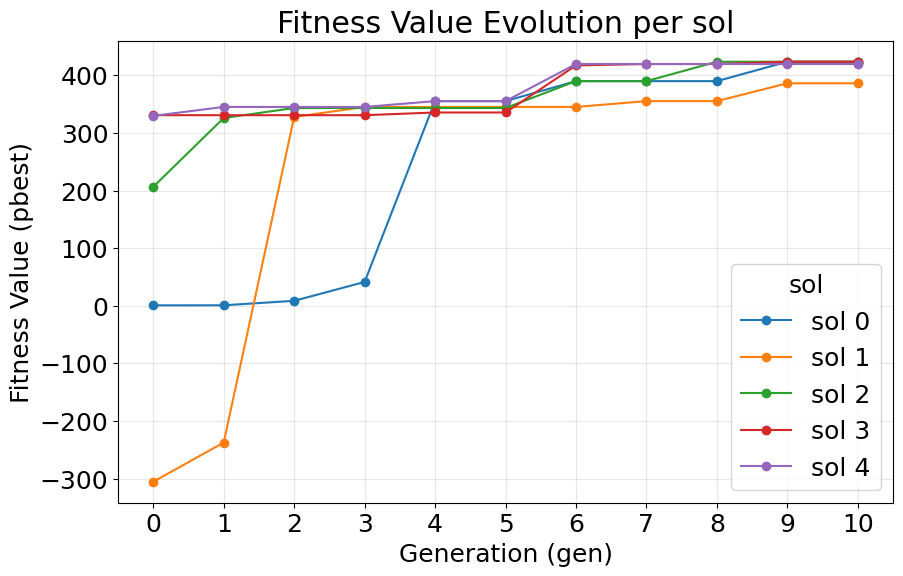

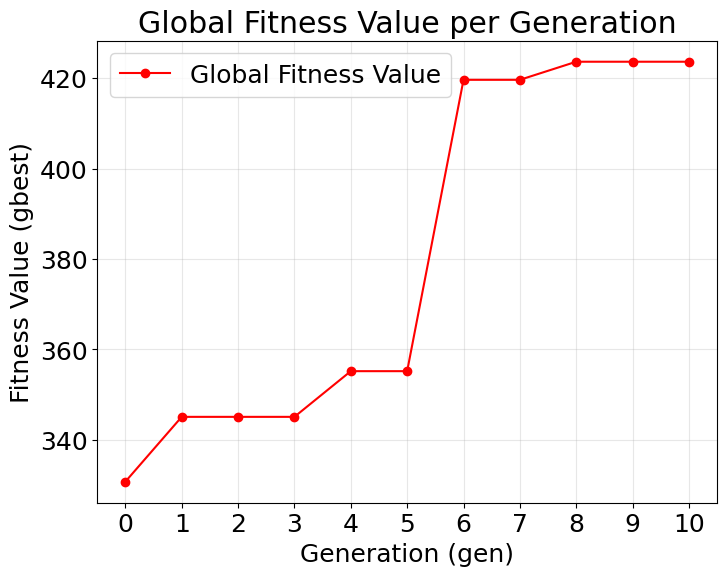

In [8]:
# 繪製搜索圖
SSO_searcher.plot()

# 3. 讀取 Checkpoint 使用說明

---

📦 功能說明

### A. 獲取最佳參數 (gBest)
- 支持從整個 Checkpoint 中提取全局最佳參數（gBest）。
- 可將最佳參數導入到自定義的 `fitness function` 進行後續處理或計算。

### B. 繪製圖表
- 提供 `plot()` 函數，可視化：
  - **pBest 圖表**：展示個體最佳適應度 (Personal Best, pBest) 隨世代 (Generation) 的演化趨勢。
  - **gBest 圖表**：展示全局最佳適應度 (Global Best, gBest) 隨世代 (Generation) 的演化趨勢。


### 注意事項
- 檔名裡面的 'ggen8_gsol2' 這種東西請勿更改，因為目前是用這個去索引最好的解。
- 也可以直接從檔案裡面的最後的['g'][2]、['g'][3]讀取，這個需要直接改load_result的邏輯就好。

In [10]:
# 設定讀取路徑
result_file = r"D:\pythonProject\IC Lab\Gait_analysis\pyskl\colab\sso_result\test_ggen8_gsol2_searchtime0.009520769119262695_682ffc41-804a-4131-accc-0f3b1454e81b.pkl"
SSO_searcher.load_result(result_file)

# 獲取這個紀錄檔中gbest solution
best_params = SSO_searcher.best_params

# 導入到fitness function
value, record_message = fitness(best_params)

print(f"fitness value: {value}")
print(f"Record_message: {record_message}")


🔄 Loading from saved checkpoint...
📂 File ggen: 8, gsol: 2
📝 Record Information
🔍 Record Message: {'val_acc': 423.614771460348, 'test_acc': 416.414771460348, 'train_time': 0.0}
🔧 Parameters: [   7.76615424   79.         -309.            1.            1.23859009]
{0: {0: {'params': (0.0, 2.0, 5.0, 2.0, 0.3), 'message': {'val_acc': 0.6000000000000001, 'test_acc': -3.0, 'train_time': 0.0}, 'p': ((0.0, 2.0, 5.0, 2.0, 0.3), 0.6000000000000001), 'g': ((0.0, 2.0, 5.0, 2.0, 0.3), 0.6000000000000001)}, 1: {'params': (-1.4699119022263947, -79.0, 250.0, 2.0, 0.7482190679309062), 'message': {'val_acc': -305.579218268768, 'test_acc': -309.179218268768, 'train_time': 0.0}, 'p': ((-1.4699119022263947, -79.0, 250.0, 2.0, 0.7482190679309062), -305.579218268768), 'g': ((0.0, 2.0, 5.0, 2.0, 0.3), 0.6000000000000001)}, 2: {'params': (-7.193556902164964, -111.0, -232.0, 2.0, 0.2104047044007079), 'message': {'val_acc': 206.45152090935645, 'test_acc': 202.85152090935645, 'train_time': 0.0}, 'p': ((-7.193556

❌ Save file not found!


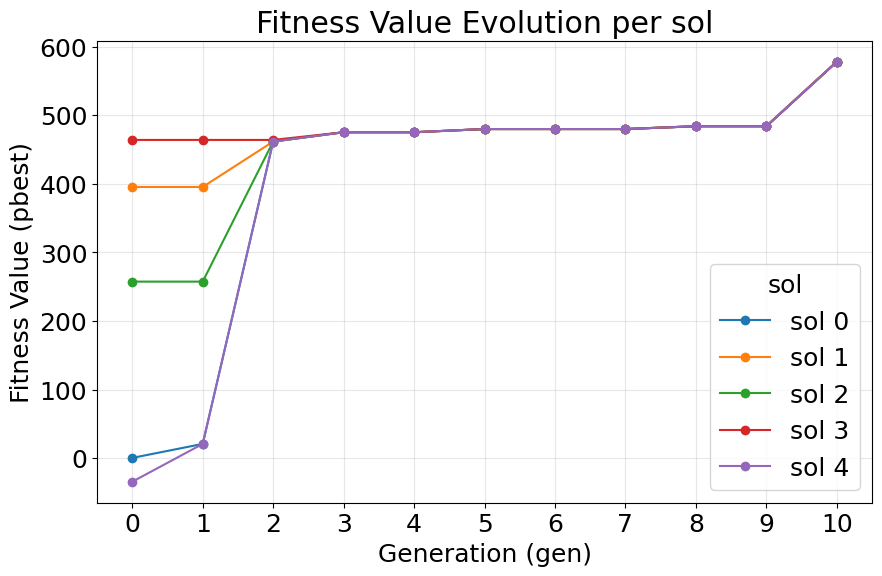

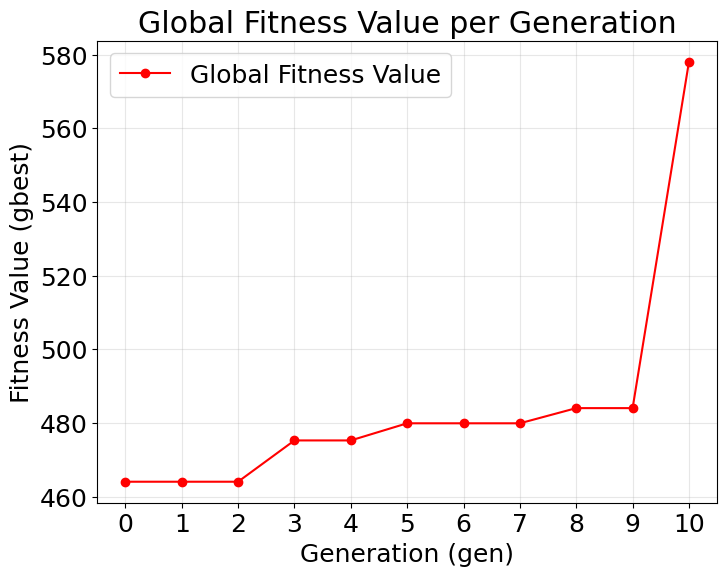

In [10]:
checkpoint_file = r"D:\pythonProject\IC Lab\Gait_analysis\pyskl\colab\sso_result\test_ggen8_gsol0_searchtime0.003998279571533203_d02d7e04-8871-40d4-a1a2-1aad9bc9cc44.pkl"
SSO_searcher.load(checkpoint_file)
SSO_searcher.plot()

In [11]:
# 假設 gen 和 sol 的索引
gen = 2
sol = 3

# 提取數據
g_params, g_value = SSO_searcher.ckpt[gen][sol]['g']  # 指定 gen，運行到指定 sol 的 gbest 的變數值及適應度值
p_params, p_value = SSO_searcher.ckpt[gen][sol]['p']  # 指定 gen，運行到指定 sol 的 pbest 的變數值及適應度值
params = SSO_searcher.ckpt[gen][sol]['params']        # 指定 gen 及指定 sol 的參數值
message = SSO_searcher.ckpt[gen][sol]['message']      # 指定 gen 及指定 sol 的紀錄訊息

# 打印输出
print(f"=== **AT** Generation {gen}, Solution {sol} ===")
print(f"🌟 Global Best Fitness: {g_value}")
print(f"🌟 Global Best Params : {g_params}")

print(f"🔍 Personal Best Fitness: {p_value}")
print(f"🔍 Personal Best Params : {p_params}")

print(f"🔧 Parameters: {params}")
print(f"📝 Record Message: {message}")
print("==============================")


=== **AT** Generation 2, Solution 3 ===
🌟 Global Best Fitness: 464.0804795488671
🌟 Global Best Params : (2.3741887844878207, 70.0, -400.0, 5.0, 0.8443755823482756)
🔍 Personal Best Fitness: 464.0804795488671
🔍 Personal Best Params : (2.3741887844878207, 70.0, -400.0, 5.0, 0.8443755823482756)
🔧 Parameters: (2.3741887844878207, 70.0, -129.0, 5.0, 0.8443755823482756)
📝 Record Message: {'val_acc': 461.70629076437933, 'test_acc': 460.26629076437933, 'train_time': 0.0}


# **快速入門**

In [12]:
# 設定初始解 >> >> 詳細說明請看'自訂初始化參數'
params = {
    'x1': 0,
    'x2': 2,
    'x3': 5,
    'x4': 2,
    'x5': 0.3,
    'x6': 1,
    'x8': 8,
}

# 設定要搜索的變數 & 範圍  >> 詳細說明請看'搜索範圍設定'
params_range = {
    'x1': (-10.0, 10.0),
    'x2': (-125, 135),
    'x3': (-500, 500),
    'x4': [1, 2, 5],
    'x5': (-0.12, 1.38)
}

# 不用動
def get_param(X, keys=params_range.keys(), params=params):
    """
    Update `param` dictionary based on `keys` and corresponding values from `X`.

    Parameters:
        X (numpy.ndarray): Array of parameter values corresponding to the keys.
        keys (list): List of parameter names (keys) used to map values in X.
        params_range (dict): Search range for each parameter, where values can be
                             tuples (for range) or lists (for discrete options).

    Returns:
        dict: Updated `param` dictionary with values from `X`, converting to int if needed.
    """
    # 創建 `param` 的拷貝，避免修改原始字典
    param = params.copy()

    # 根據 keys 中的索引更新 param 中對應的鍵
    for i, key in enumerate(keys):
        # 判斷該參數是否需要轉換為整數
        boundary = params_range[key]
        if (
            isinstance(boundary, tuple) and all(isinstance(b, int) for b in boundary)
        ) or (
            isinstance(boundary, list) and all(isinstance(b, int) for b in boundary)
        ):
            # 如果是整數範圍或整數列表，將值轉換為整數
            param[key] = int(X[i])
        else:
            # 否則保留原類型
            param[key] = X[i]

    return param

# 適應度函數(自訂義)
def fitness(X, params_range=params_range, params=params):
    """
    Fitness function

    Parameters:
        X (numpy.ndarray): Array of parameter values for the model.
                           The array is expected to be a 1D array where each element corresponds 
                           to a specific parameter defined in `params_range.keys()`.

                           Example:
                           X = [best_weight_decay_1, best_lamda, best_al, best_earlystop, ...]

    Returns:
        fitness_value (float): Calculated fitness value based on the parameter values in X.
        record_message (dict): Dictionary containing the following metrics:
                               - 'val_acc' (float): Validation accuracy (fitness value).
                               - 'test_acc' (float): Test accuracy.
                               - 'train_time' (float): Time taken to compute the fitness value.
    """
    # 這個可以不用動，改下面就好了。
    param = get_param(keys=params_range.keys(), params=params, X=X)
    

    # ---------------從這邊開始改---------------
    start_time = time.time()
    
    fitness_value = ((int(param['x6']) + param['x1'] + int(param['x2']) * param['x5']) - int(param['x3'])) + int(param['x8'])/ int(param['x4'])
    
    test_acc = ((int(param['x6']) + param['x1'] + int(param['x2']) * param['x5']) - int(param['x3'])) + int(param['x8']) / int(param['x4']) /10
    train_time = time.time() - start_time
    # train_time 也可以從自定義的腳本獲取，這個夾法會記錄到檔案寫入時間，比較不建議

    # 可按需求存資訊
    # Record message 建議使用字典，以便索引
    record_message = {
                    'val_acc': fitness_value,
                    'test_acc': test_acc,
                    'train_time':train_time,            
                }
    
    return fitness_value, record_message

📄 記錄檔已儲存至：sso_result/test_ggen7_gsol0_searchtime0.004504680633544922_05a16eb1-0eaf-4e1c-abcd-91639e820c62.pkl
----------------------------------------
🚀 Search Results Summary
✅ Search 完成！
🔍 最佳解所在世代編號：7
🔍 最佳解索引編號：0
----------------------------------------
🏆 Optimal Solution Details:
  - Optimal Solution: {'params': (-2.176837114500376, -83.0, 224.0, 5.0, 1.2107820881806965), 'message': {'val_acc': -324.07175043349815, 'test_acc': -325.51175043349815, 'train_time': 0.0}, 'p': ((-2.176837114500376, -83.0, 224.0, 5.0, 1.2107820881806965), -324.07175043349815), 'g': ((-2.176837114500376, -83.0, 224.0, 5.0, 1.2107820881806965), -324.07175043349815)}
  - Optimal Fitness Value: -324.071750
----------------------------------------
⏱️ SSO Search Total Time: 0.00 seconds


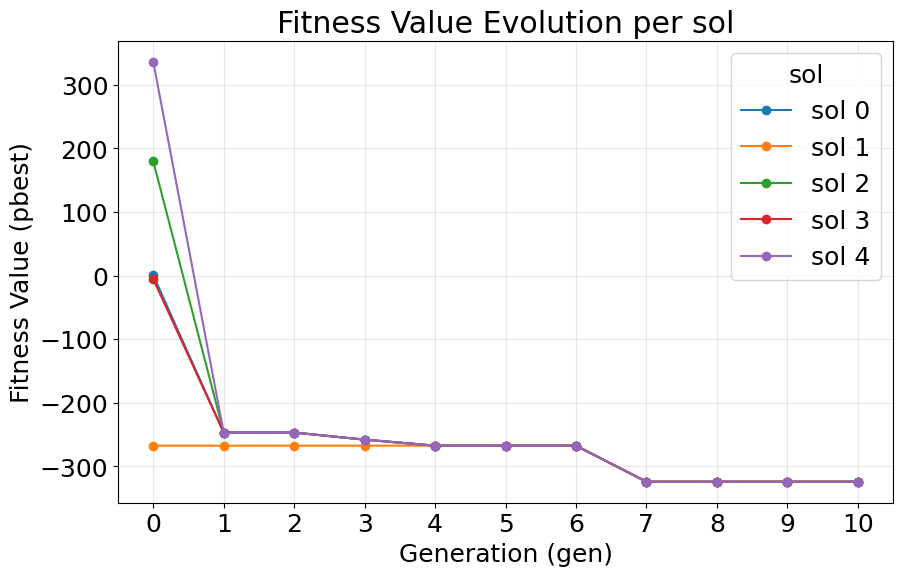

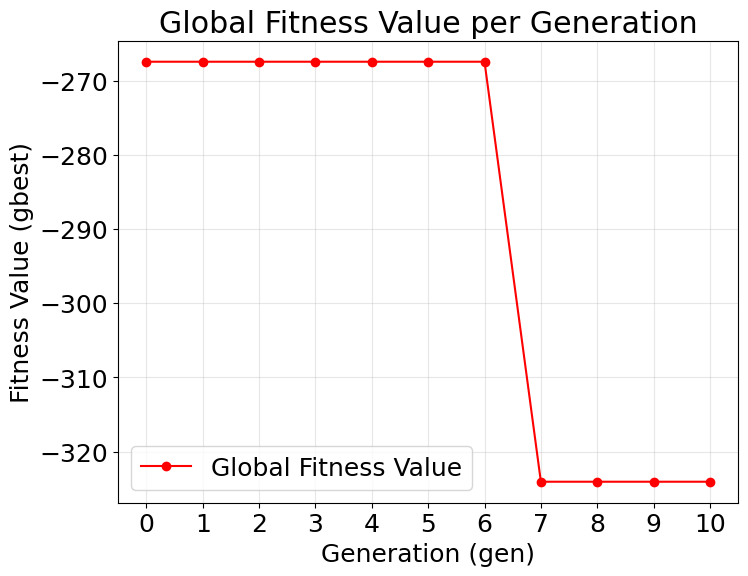

In [13]:
SSO_searcher = SSO(Ngen=10,                 # 世代數
    Nsol=5,                                 # 解的數量
    Cg=0.4,                                 # 全局最佳解的權重
    Cp=0.7,                                 # 個體最佳解的權重
    Cw=0.9,                                 # 隨機解的權重
    save_name='test',                       # 記錄檔儲存前綴
    fitness=fitness,                        # 適應度函數
    base_param=params,                      # 基礎參數 (可選)
    boundary=params_range,                  # 支持 tuple 或 list (詳細說明請參照前述)
    direction="minimize",                   # 優化方向 ('maximize', 'minimize')
    )

# 直接運行
SSO_searcher.run()
SSO_searcher.plot()

In [14]:
GBEST_PARAMS = SSO_searcher.best_params
value, message = fitness(GBEST_PARAMS)
print(value)
print(message)

-324.07175043349815
{'val_acc': -324.07175043349815, 'test_acc': -325.51175043349815, 'train_time': 0.0}


# 參數敏感度分析

In [15]:
# 如果不能用，請執行這個 : 
# !pip install --upgrade nbformat

In [16]:
# 測試minimun
files = [
    r'D:\pythonProject\IC Lab\Gait_analysis\pyskl\colab\sso_result\test_ggen1_gsol0_searchtime0.003000020980834961_126ba777-5c15-448f-b8a5-c3d5509f4faa.pkl',
    r'D:\pythonProject\IC Lab\Gait_analysis\pyskl\colab\sso_result\test_ggen7_gsol0_searchtime0.0030112266540527344_f7ab4f38-73fc-4894-86d6-2214be9a5ddb.pkl'
]

label_map = {
    'x4' : ['a', 'b', 'c']
}

SSO_searcher.sensitivity_analysis(files=files, y_value='val_acc', label_map=label_map)


🔄 Loading from saved checkpoint...
📂 File ggen: 1, gsol: 0
📝 Record Information
🔍 Record Message: {'val_acc': 347.1666950770459, 'test_acc': 343.5666950770459, 'train_time': 0.0}
🔧 Parameters: [-1.13330492e+00 -2.90000000e+01 -3.52000000e+02  2.00000000e+00
  3.00000000e-01]

🔄 Loading from saved checkpoint...
📂 File ggen: 7, gsol: 0
📝 Record Information
🔍 Record Message: {'val_acc': -474.33051486015523, 'test_acc': -481.5305148601552, 'train_time': 0.0}
🔧 Parameters: [ -7.23003049 -96.         428.           1.           0.50104671]


In [17]:
# 測試maximun

files = [
    r'D:\pythonProject\IC Lab\Gait_analysis\pyskl\colab\sso_result\test_ggen1_gsol0_searchtime0.003000020980834961_126ba777-5c15-448f-b8a5-c3d5509f4faa.pkl',
    r'D:\pythonProject\IC Lab\Gait_analysis\pyskl\colab\sso_result\test_ggen7_gsol0_searchtime0.0030112266540527344_f7ab4f38-73fc-4894-86d6-2214be9a5ddb.pkl'
]

label_map = {
    'x4' : ['a', 'b', 'c']
}
SSO_searcher = SSO(Ngen=10,                 # 世代數
    Nsol=5,                                 # 解的數量
    Cg=0.4,                                 # 全局最佳解的權重
    Cp=0.7,                                 # 個體最佳解的權重
    Cw=0.9,                                 # 隨機解的權重
    save_name='test',                       # 記錄檔儲存前綴
    fitness=fitness,                        # 適應度函數
    base_param=params,                      # 基礎參數 (可選)
    boundary=params_range,                  # 支持 tuple 或 list (詳細說明請參照前述)
    direction="maximize",                   # 優化方向 ('maximize', 'minimize')
    )
SSO_searcher.sensitivity_analysis(files=files, y_value='val_acc', label_map=label_map)


🔄 Loading from saved checkpoint...
📂 File ggen: 1, gsol: 0
📝 Record Information
🔍 Record Message: {'val_acc': 347.1666950770459, 'test_acc': 343.5666950770459, 'train_time': 0.0}
🔧 Parameters: [-1.13330492e+00 -2.90000000e+01 -3.52000000e+02  2.00000000e+00
  3.00000000e-01]

🔄 Loading from saved checkpoint...
📂 File ggen: 7, gsol: 0
📝 Record Information
🔍 Record Message: {'val_acc': -474.33051486015523, 'test_acc': -481.5305148601552, 'train_time': 0.0}
🔧 Parameters: [ -7.23003049 -96.         428.           1.           0.50104671]
